<a href="https://colab.research.google.com/github/Valen-Nneji-007/pytorch-intro-/blob/main/My_Aircraft_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib
import matplotlib.pyplot as plt

# Check the version
print(torch.__version__)
print(torchvision.__version__)

2.9.0+cpu
0.24.0+cpu


In [34]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # or (256, 256), etc.
    transforms.ToTensor()
])


In [35]:
# setup training data
from torchvision import datasets
train_data=datasets.FGVCAircraft(
    root="data",
    split="trainval",
    annotation_level="variant",
    transform=transform,
    target_transform=None,
    download= True
)

test_data = datasets.FGVCAircraft(
    root="data",
    split="test",
    annotation_level="variant",
    download=True,
    target_transform=None,
    transform=transform
)


In [36]:
len(train_data), len(test_data)

(6667, 3333)

In [37]:
image, label = train_data[0]
train_data[0]

(tensor([[[0.8588, 0.8588, 0.8588,  ..., 0.8667, 0.8667, 0.8667],
          [0.8588, 0.8588, 0.8588,  ..., 0.8667, 0.8667, 0.8706],
          [0.8549, 0.8549, 0.8549,  ..., 0.8627, 0.8667, 0.8667],
          ...,
          [0.3098, 0.1804, 0.1843,  ..., 0.3490, 0.1843, 0.0510],
          [0.2392, 0.0980, 0.1490,  ..., 0.3608, 0.0706, 0.0039],
          [0.1098, 0.1098, 0.0667,  ..., 0.2510, 0.0196, 0.0000]],
 
         [[0.8588, 0.8588, 0.8588,  ..., 0.8667, 0.8667, 0.8667],
          [0.8588, 0.8588, 0.8588,  ..., 0.8667, 0.8667, 0.8706],
          [0.8549, 0.8549, 0.8549,  ..., 0.8627, 0.8667, 0.8667],
          ...,
          [0.3255, 0.1843, 0.1882,  ..., 0.4275, 0.2314, 0.0588],
          [0.2627, 0.1098, 0.1647,  ..., 0.4392, 0.0902, 0.0039],
          [0.1255, 0.1255, 0.0745,  ..., 0.2980, 0.0235, 0.0000]],
 
         [[0.8588, 0.8588, 0.8588,  ..., 0.8667, 0.8667, 0.8667],
          [0.8588, 0.8588, 0.8588,  ..., 0.8667, 0.8667, 0.8706],
          [0.8549, 0.8549, 0.8549,  ...,

In [38]:
class_names = train_data.classes
class_names

['707-320',
 '727-200',
 '737-200',
 '737-300',
 '737-400',
 '737-500',
 '737-600',
 '737-700',
 '737-800',
 '737-900',
 '747-100',
 '747-200',
 '747-300',
 '747-400',
 '757-200',
 '757-300',
 '767-200',
 '767-300',
 '767-400',
 '777-200',
 '777-300',
 'A300B4',
 'A310',
 'A318',
 'A319',
 'A320',
 'A321',
 'A330-200',
 'A330-300',
 'A340-200',
 'A340-300',
 'A340-500',
 'A340-600',
 'A380',
 'ATR-42',
 'ATR-72',
 'An-12',
 'BAE 146-200',
 'BAE 146-300',
 'BAE-125',
 'Beechcraft 1900',
 'Boeing 717',
 'C-130',
 'C-47',
 'CRJ-200',
 'CRJ-700',
 'CRJ-900',
 'Cessna 172',
 'Cessna 208',
 'Cessna 525',
 'Cessna 560',
 'Challenger 600',
 'DC-10',
 'DC-3',
 'DC-6',
 'DC-8',
 'DC-9-30',
 'DH-82',
 'DHC-1',
 'DHC-6',
 'DHC-8-100',
 'DHC-8-300',
 'DR-400',
 'Dornier 328',
 'E-170',
 'E-190',
 'E-195',
 'EMB-120',
 'ERJ 135',
 'ERJ 145',
 'Embraer Legacy 600',
 'Eurofighter Typhoon',
 'F-16A/B',
 'F/A-18',
 'Falcon 2000',
 'Falcon 900',
 'Fokker 100',
 'Fokker 50',
 'Fokker 70',
 'Global Express

In [39]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'707-320': 0,
 '727-200': 1,
 '737-200': 2,
 '737-300': 3,
 '737-400': 4,
 '737-500': 5,
 '737-600': 6,
 '737-700': 7,
 '737-800': 8,
 '737-900': 9,
 '747-100': 10,
 '747-200': 11,
 '747-300': 12,
 '747-400': 13,
 '757-200': 14,
 '757-300': 15,
 '767-200': 16,
 '767-300': 17,
 '767-400': 18,
 '777-200': 19,
 '777-300': 20,
 'A300B4': 21,
 'A310': 22,
 'A318': 23,
 'A319': 24,
 'A320': 25,
 'A321': 26,
 'A330-200': 27,
 'A330-300': 28,
 'A340-200': 29,
 'A340-300': 30,
 'A340-500': 31,
 'A340-600': 32,
 'A380': 33,
 'ATR-42': 34,
 'ATR-72': 35,
 'An-12': 36,
 'BAE 146-200': 37,
 'BAE 146-300': 38,
 'BAE-125': 39,
 'Beechcraft 1900': 40,
 'Boeing 717': 41,
 'C-130': 42,
 'C-47': 43,
 'CRJ-200': 44,
 'CRJ-700': 45,
 'CRJ-900': 46,
 'Cessna 172': 47,
 'Cessna 208': 48,
 'Cessna 525': 49,
 'Cessna 560': 50,
 'Challenger 600': 51,
 'DC-10': 52,
 'DC-3': 53,
 'DC-6': 54,
 'DC-8': 55,
 'DC-9-30': 56,
 'DH-82': 57,
 'DHC-1': 58,
 'DHC-6': 59,
 'DHC-8-100': 60,
 'DHC-8-300': 61,
 'DR-400': 62,


In [40]:
train_data[0][0].shape

torch.Size([3, 224, 224])

Image shape: torch.Size([3, 224, 224])


Text(0.5, 1.0, 'Embraer Legacy 600')

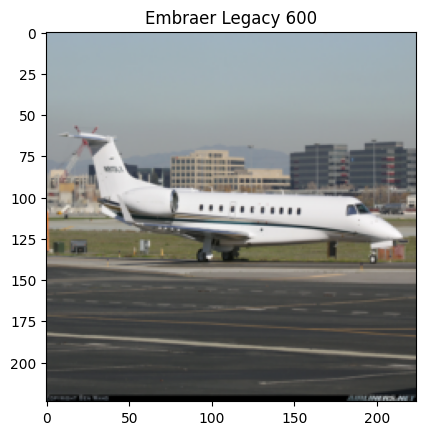

In [41]:
import matplotlib.pyplot as plt
image, label = train_data[2345]
print(f"Image shape: {image.shape}")
img = image.permute(1,2,0)
plt.imshow(img)
plt.title(class_names[label])

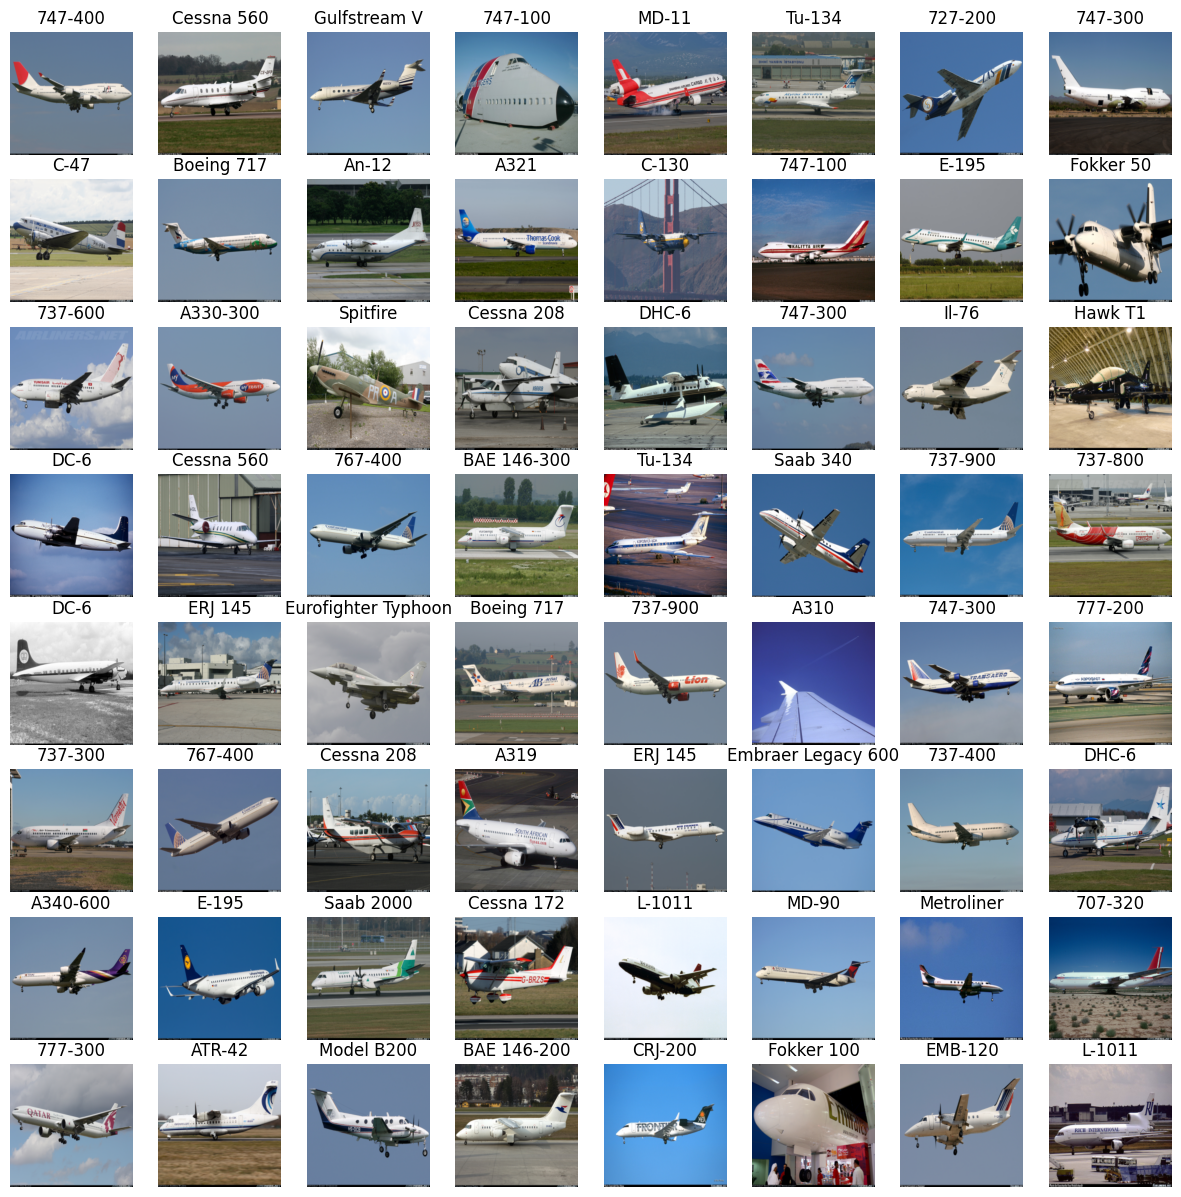

In [42]:
# show all the Aircrafts and theri labels
torch.manual_seed(42)
fig = plt.figure(figsize=(15, 15))
rows, cols = 8, 8
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  image = img.permute(1, 2, 0)
  plt.imshow(image)
  plt.title(class_names[label])
  plt.axis(False);



### 2. Prepare DataLoader

In [43]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# Turn tha datasets into iterables (atches
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader =  DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d69ac12f3b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7d69904dc5f0>)

In [44]:
len(train_dataloader), len(test_dataloader)

(209, 105)

In [45]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

Image size: torch.Size([3, 224, 224])
Label: 10, label size: torch.Size([])


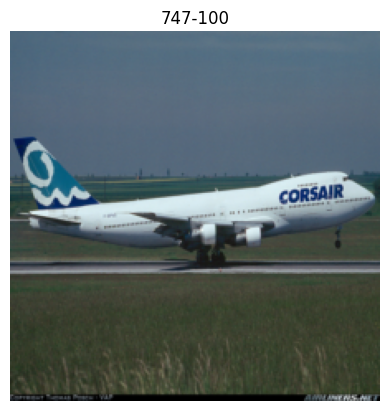

In [46]:
# Show a sample
torch.manual_seed(41)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
image= img.permute(1, 2, 0)
plt.imshow(image)
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

In [47]:
from torch import nn
class AircraftModel0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*28*28,
                  out_features=output_shape)
    )

  def forward(self, x):
    x= self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.conv_block_3(x)
    x= self.layer_stack(x)
    return x


In [48]:
model_0 = AircraftModel0(input_shape=3,
                         hidden_units=10,
                         output_shape=len(class_names)).to("cpu")

model_0

AircraftModel0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linea

In [49]:
!pip install torchinfo

In [50]:
from torchinfo import summary
summary(model_0, input_size=None)

Layer (type:depth-idx)                   Param #
AircraftModel0                           --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       280
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       910
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-6                       910
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       910
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-11                      910
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      910
│    └─ReLU: 2-14                        --
│    └─MaxPool2d: 2-15                   --
├─Sequential: 1-4                        --
│    └─Flatten: 2-16                     --
│    └─Linear: 2-17  

In [51]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc= (correct / len(y_pred)) * 100

In [52]:
# Setup for loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr =0.1)

In [53]:
dummy_x = torch.rand(1, 3, 224, 224)
model_0(dummy_x)

tensor([[ 0.0270, -0.0251,  0.0332,  0.0351, -0.0081, -0.0459, -0.0441,  0.0200,
         -0.0414, -0.0041, -0.0208,  0.0469,  0.0029,  0.0025,  0.0378,  0.0040,
         -0.0044, -0.0174,  0.0097,  0.0105, -0.0047,  0.0386, -0.0173, -0.0091,
         -0.0114, -0.0251,  0.0300, -0.0118, -0.0192, -0.0271, -0.0002,  0.0288,
          0.0118,  0.0425, -0.0086, -0.0176,  0.0132, -0.0020, -0.0124,  0.0286,
         -0.0124,  0.0109, -0.0136, -0.0352, -0.0055,  0.0669, -0.0013,  0.0301,
          0.0285,  0.0508,  0.0349, -0.0023, -0.0612, -0.0145, -0.0290, -0.0108,
          0.0339,  0.0037,  0.0036, -0.0111,  0.0179, -0.0143, -0.0498,  0.0285,
          0.0421,  0.0070,  0.0211,  0.0279,  0.0494,  0.0308, -0.0121,  0.0228,
         -0.0239,  0.0422,  0.0250,  0.0096, -0.0203, -0.0149, -0.0456,  0.0286,
         -0.0010, -0.0059,  0.0158,  0.0024, -0.0154, -0.0040, -0.0108, -0.0429,
         -0.0295, -0.0010,  0.0002,  0.0440,  0.0463, -0.0427, -0.0274,  0.0135,
          0.0126, -0.0119, -

### Creating training and testing function for model_0

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [55]:
def train_funct(model: torch.nn.Module,
                dataloader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim.Optimizer
                ):

  train_acc, train_loss = 0, 0



  for batch, (X, y) in enumerate(dataloader):

    X,y = X.to(device), y.to(device)

    model.train()

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_prob = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_prob == y).sum().item()/len(y_pred)

  train_acc = train_acc / len(dataloader)
  train_loss = train_loss / len(dataloader)
  return train_loss, train_acc







In [56]:
def test_function(model: torch.nn.Module,
                  dataloader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  ):

  # Test Mode
  model.eval()

  test_acc, test_loss = 0,0

  with torch.inference_mode():

    for batch, (X,y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred = model(X)

      loss = loss_fn(test_pred, y)
      test_loss += loss.item()


      test_pred_prob = test_pred.argmax(dim=1)
      test_acc = (test_pred_prob == y).sum().item() / len(test_pred_prob)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc







In [ ]:
from tqdm.auto import tqdm

def train_and_test(model:torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   test_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   epochs: int,
                   ):

  results = {"train_loss":[],
                    "train_acc":[],
                    "test_loss":[],
                     "test_acc":[]}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):

  # train loop
    train_acc, train_loss = train_funct(model_0,
                                      train_dataloader,
                                      loss_fn,
                                      optimizer)

  # #test loss
    test_loss, test_acc = test_function(model_0,
                                      test_dataloader,
                                      loss_fn,
                                      )

    print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}  | test_loss: {test_loss:.4f}  | test_acc: {test_acc:.4f}")

    # Update the resukt dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

In [ ]:
# Lets train for 5 epoch
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0 = AircraftModel0(input_shape=3,
                         hidden_units=10,
                         output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

model_0_results = train_and_test(model=model_0,
                                 train_dataloader=train_dataloader,
                                 test_dataloader=test_dataloader,
                                 loss_fn=loss_fn,
                                 optimizer=optimizer,
                                 epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0106 | train_acc: 4.6122  | test_loss: 4.6051  | test_acc: 0.0000
Epoch: 2 | train_loss: 0.0103 | train_acc: 4.6049  | test_loss: 4.5972  | test_acc: 0.0000
Epoch: 3 | train_loss: 0.0108 | train_acc: 4.5942  | test_loss: 4.5958  | test_acc: 0.0000
